## Import
Librerie per manipolazione dati, preprocessing, clustering e statistica.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, unicodedata
from scipy import stats

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)

## Caricamento e pulizia dati
Carica il dataset di mobilità, armonizza i nomi dei paesi e normalizza la colonna *Fewer Opportunities* in Yes/No/Unknown.

In [ ]:
mob = pd.read_csv("df_mobility_hicp.csv").drop(columns=["Unnamed: 0"])

country_clean = {
    "Czech Republic": "Czechia",
    "Turkey": "T\u00fcrkiye",
    "The Republic of North Macedonia": "North Macedonia",
}
mob["Sending Country"] = mob["Sending Country"].replace(country_clean)
mob["Receiving Country"] = mob["Receiving Country"].replace(country_clean)

def clean_fewer_opportunities(v):
    v = str(v).strip().lower()
    return {"yes": "Yes", "1": "Yes", "no": "No", "0": "No"}.get(v, "Unknown")

mob["Fewer_Opportunities_clean"] = mob["Fewer Opportunities"].apply(clean_fewer_opportunities)

## Feature engineering — campo di studi
Mappa i valori grezzi di *Field of Education* sui 10 macro-campi ISCED-F, per evitare un one-hot troppo sparso.

TODO: con il database completo rifare il mapping

In [ ]:
FIELD_MAP = {
    'Education':'Education','Education science':'Education',
    'Teacher training with subject specialization':'Education',
    'Teacher training without subject specialization':'Education',
    'Training for pre-school teachers':'Education',
    'Arts':'Arts and humanities','Arts and humanities':'Arts and humanities',
    'Audio-visual techniques and media production':'Arts and humanities',
    'Fine arts':'Arts and humanities','History and archaeology':'Arts and humanities',
    'Humanities (except languages)':'Arts and humanities','Language acquisition':'Arts and humanities',
    'Languages':'Arts and humanities','Literature and linguistics':'Arts and humanities',
    'Music and performing arts':'Arts and humanities','Philosophy and ethics':'Arts and humanities',
    'Religion and theology':'Arts and humanities','Fashion, interior and industrial design':'Arts and humanities',
    'Journalism and information':'Social sciences, journalism and information',
    'Journalism and reporting':'Social sciences, journalism and information',
    'Political sciences and civics':'Social sciences, journalism and information',
    'Psychology':'Social sciences, journalism and information',
    'Social and behavioural sciences':'Social sciences, journalism and information',
    'Social sciences, journalism and information':'Social sciences, journalism and information',
    'Sociology and cultural studies':'Social sciences, journalism and information',
    'Accounting and taxation':'Business, administration and law','Business and administration':'Business, administration and law',
    'Business, administration and law':'Business, administration and law','Economics':'Business, administration and law',
    'Finance, banking and insurance':'Business, administration and law','Law':'Business, administration and law',
    'Management and administration':'Business, administration and law','Marketing and advertising':'Business, administration and law',
    'Secretarial and office work':'Business, administration and law','Work skills':'Business, administration and law',
    'Biochemistry':'Natural sciences, mathematics and statistics','Biological and related sciences':'Natural sciences, mathematics and statistics',
    'Biology':'Natural sciences, mathematics and statistics','Chemistry':'Natural sciences, mathematics and statistics',
    'Earth sciences':'Natural sciences, mathematics and statistics','Environment':'Natural sciences, mathematics and statistics',
    'Environmental sciences':'Natural sciences, mathematics and statistics','Mathematics':'Natural sciences, mathematics and statistics',
    'Mathematics and statistics':'Natural sciences, mathematics and statistics','Physical sciences':'Natural sciences, mathematics and statistics',
    'Physics':'Natural sciences, mathematics and statistics','Statistics':'Natural sciences, mathematics and statistics',
    'Computer use':'Information and Communication Technologies (ICTs)',
    'Information and Communication Technologies (ICTs)':'Information and Communication Technologies (ICTs)',
    'Software and applications development and analysis':'Information and Communication Technologies (ICTs)',
    'Architecture and construction':'Engineering, manufacturing and construction',
    'Architecture and town planning':'Engineering, manufacturing and construction',
    'Building and civil engineering':'Engineering, manufacturing and construction',
    'Chemical engineering and processes':'Engineering, manufacturing and construction',
    'Electricity and energy':'Engineering, manufacturing and construction',
    'Electronics and automation':'Engineering, manufacturing and construction',
    'Engineering and engineering trades':'Engineering, manufacturing and construction',
    'Engineering, manufacturing and construction':'Engineering, manufacturing and construction',
    'Environmental protection technology':'Engineering, manufacturing and construction',
    'Food processing':'Engineering, manufacturing and construction',
    'Manufacturing and processing':'Engineering, manufacturing and construction',
    'Mechanics and metal trades':'Engineering, manufacturing and construction',
    'Mining and extraction':'Engineering, manufacturing and construction',
    'Motor vehicles, ships and aircraft':'Engineering, manufacturing and construction',
    'Textiles (clothes, footwear and leather)':'Engineering, manufacturing and construction',
    'Agriculture':'Agriculture, forestry, fisheries and veterinary',
    'Agriculture, forestry, fisheries and veterinary':'Agriculture, forestry, fisheries and veterinary',
    'Crop and livestock production':'Agriculture, forestry, fisheries and veterinary',
    'Forestry':'Agriculture, forestry, fisheries and veterinary','Veterinary':'Agriculture, forestry, fisheries and veterinary',
    'Dental studies':'Health and welfare','Health':'Health and welfare',
    'Medical diagnostic and treatment technology':'Health and welfare','Medicine':'Health and welfare',
    'Nursing and midwifery':'Health and welfare','Pharmacy':'Health and welfare',
    'Therapy and rehabilitation':'Health and welfare','Welfare':'Health and welfare',
    'Social work and counselling':'Health and welfare','Child care and youth services':'Health and welfare',
    'Domestic services':'Services','Hotel, restaurants and catering':'Services',
    'Military and defence':'Services','Personal services':'Services','Security services':'Services',
    'Services':'Services','Sports':'Services','Transport services':'Services',
    'Travel, tourism and leisure':'Services','Wholesale and retail sales':'Services',
}
mob["Field_Group"] = mob["Field of Education"].map(FIELD_MAP)

## Feature engineering — regioni
Raggruppa i paesi in macro-regioni europee (Nord/Sud/Ovest/Est + resto del mondo) invece di tenerli come singole categorie.

In [ ]:
REGION = {
 'Denmark':'Northern Europe','Estonia':'Northern Europe','Finland':'Northern Europe','Iceland':'Northern Europe',
 'Ireland':'Northern Europe','Latvia':'Northern Europe','Lithuania':'Northern Europe','Norway':'Northern Europe',
 'Sweden':'Northern Europe','United Kingdom':'Northern Europe',
 'Croatia':'Southern Europe','Cyprus':'Southern Europe','Greece':'Southern Europe','Italy':'Southern Europe',
 'Malta':'Southern Europe','Portugal':'Southern Europe','Slovenia':'Southern Europe','Spain':'Southern Europe',
 'T\u00fcrkiye':'Southern Europe','Serbia':'Southern Europe','North Macedonia':'Southern Europe',
 'Austria':'Western Europe','Belgium':'Western Europe','France':'Western Europe','Germany':'Western Europe',
 'Luxembourg':'Western Europe','Netherlands':'Western Europe','Switzerland':'Western Europe',
 'Bulgaria':'Eastern Europe','Czechia':'Eastern Europe','Hungary':'Eastern Europe','Poland':'Eastern Europe',
 'Romania':'Eastern Europe','Slovakia':'Eastern Europe','Ukraine':'Eastern Europe','Azerbaijan':'Eastern Europe',
 'Algeria':'Rest of World','Argentina':'Rest of World','Japan':'Rest of World','Lebanon':'Rest of World',
 'Mexico':'Rest of World','Morocco':'Rest of World','Nepal':'Rest of World','Palestine':'Rest of World',
 'South Korea':'Rest of World','United States of America':'Rest of World'
}
mob["Sending_Region"] = mob["Sending Country"].map(REGION)
mob["Receiving_Region"] = mob["Receiving Country"].map(REGION)

## Feature engineering — HICP e frequenza paesi
Winsorizza l’indice HICP (per limitare l’effetto degli outlier legati alla Turchia), calcola il differenziale invio/ricezione e la frequenza di ciascun paese nel campione.

In [ ]:
for col in ["Sending Country HICP", "Receiving Country HICP"]:
    lo, hi = mob[col].quantile([0.01, 0.99])
    mob[col + "_w"] = mob[col].clip(lo, hi)

mob["HICP_diff_w"] = mob["Receiving Country HICP_w"] - mob["Sending Country HICP_w"]

mob["Sending_Country_Freq"] = mob["Sending Country"].map(mob["Sending Country"].value_counts(normalize=True))
mob["Receiving_Country_Freq"] = mob["Receiving Country"].map(mob["Receiving Country"].value_counts(normalize=True))

## Blocchi di colonne per il clustering
Divide le feature in tre gruppi semantici — demografiche, geo-economiche, campo di studi — così da poterle pesare in modo indipendente.

In [ ]:
demo_num_cols = ["Mobility Duration", "Participant Age"]
demo_cat_cols = ["Participant Gender", "Fewer_Opportunities_clean", "Education Level"]
geo_num_cols  = ["Sending Country HICP_w", "Receiving Country HICP_w", "HICP_diff_w",
                  "Sending_Country_Freq", "Receiving_Country_Freq"]
geo_cat_cols  = ["Sending_Region", "Receiving_Region"]
field_cat_cols = ["Field_Group"]

num_cols_all = demo_num_cols + geo_num_cols
mob[num_cols_all] = mob[num_cols_all].fillna(mob[num_cols_all].median())
print(mob[num_cols_all].isna().sum())

Mobility Duration           0
Participant Age             0
Sending Country HICP_w      0
Receiving Country HICP_w    0
HICP_diff_w                 0
Sending_Country_Freq        0
Receiving_Country_Freq      0
dtype: int64


## Pipeline di preprocessing pesato
Definisce una funzione che costruisce la matrice di feature scalando/one-hot-encodando ogni blocco con un peso configurabile, e tre combinazioni di pesi da confrontare (baseline, enfasi geo-economica, enfasi demografica/campo).

In [ ]:
def build_matrix(weights):
    ct = ColumnTransformer([
        ("demo_num", StandardScaler(), demo_num_cols),
        ("demo_cat", OneHotEncoder(handle_unknown="ignore"), demo_cat_cols),
        ("geo_num", StandardScaler(), geo_num_cols),
        ("geo_cat", OneHotEncoder(handle_unknown="ignore"), geo_cat_cols),
        ("field_cat", OneHotEncoder(handle_unknown="ignore"), field_cat_cols),
    ], transformer_weights=weights)
    Xt = ct.fit_transform(mob)
    return Xt.toarray() if hasattr(Xt, "toarray") else Xt

versions = {
    "baseline": {"demo_num": 1, "demo_cat": 1, "geo_num": 1, "geo_cat": 1, "field_cat": 1},
    "geo_economic_focus": {"demo_num": 0.5, "demo_cat": 0.5, "geo_num": 2, "geo_cat": 2, "field_cat": 1},
    "demo_field_focus": {"demo_num": 2, "demo_cat": 2, "geo_num": 0.5, "geo_cat": 0.5, "field_cat": 2},
}

: 

## Elbow e silhouette per versione
Per ciascuna versione pesata, scansiona k=2..10 con elbow e silhouette, sceglie automaticamente il k migliore (escludendo k=2, che isola solo gli outlier) e allena il KMeans finale.

In [ ]:
results = {}

for name, w in versions.items():
    Xt = build_matrix(w)
    inertias, sils = [], []
    k_range = range(2, 11)
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(Xt)
        inertias.append(km.inertia_)
        sils.append(silhouette_score(Xt, labels))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(list(k_range), inertias, marker="o")
    axes[0].set_title(f"{name} \u2014 elbow")
    axes[0].set_xlabel("k"); axes[0].set_ylabel("inertia")
    axes[1].plot(list(k_range), sils, marker="o", color="#C44E52")
    axes[1].set_title(f"{name} \u2014 silhouette")
    axes[1].set_xlabel("k"); axes[1].set_ylabel("silhouette")
    plt.tight_layout()
    plt.show()

    best_k = list(k_range)[int(np.argmax(sils[1:])) + 1]
    km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    labels_final = km_final.fit_predict(Xt)
    sil_final = silhouette_score(Xt, labels_final)

    results[name] = {"X": Xt, "k": best_k, "labels": labels_final, "silhouette": sil_final}
    print(f"{name}: best_k={best_k}, silhouette={sil_final:.3f}")

## Proiezione PCA per versione
Proietta ciascuna versione su 2 componenti principali per ispezionare visivamente quanto i cluster risultino separati.

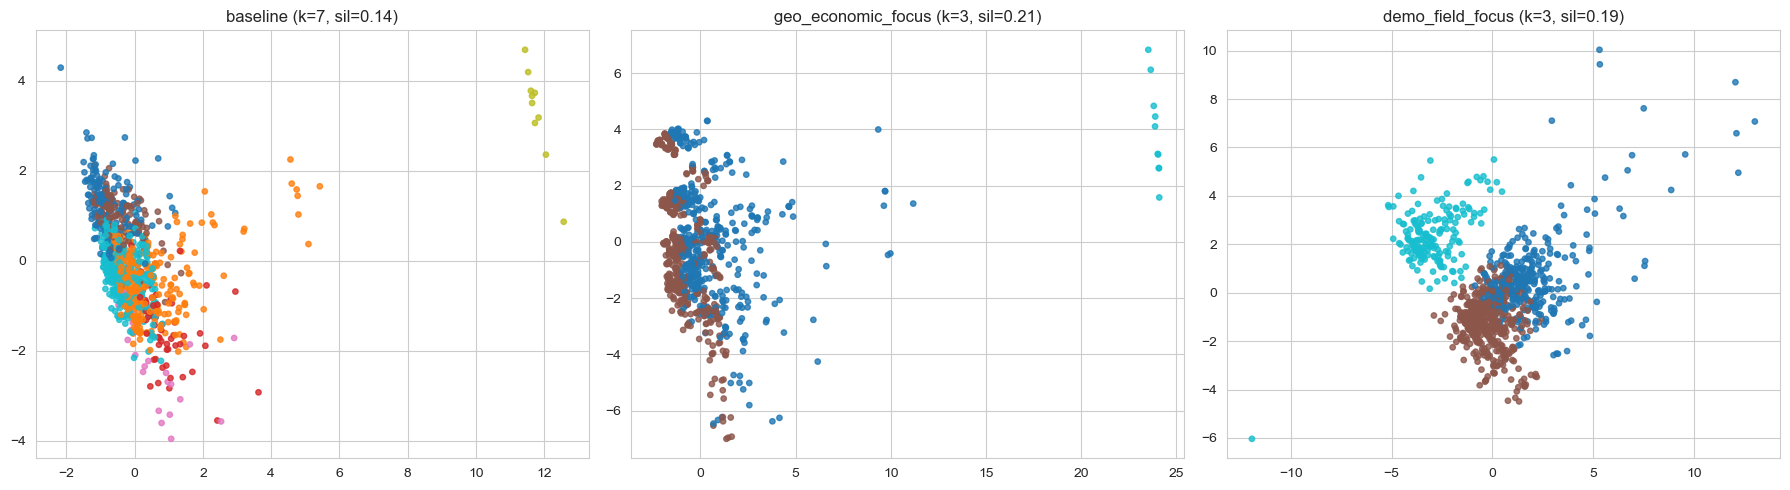

In [ ]:
fig, axes = plt.subplots(1, len(results), figsize=(6*len(results), 5))
for ax, (name, r) in zip(axes, results.items()):
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(r["X"])
    k_r, sil_r = r["k"], r["silhouette"]
    ax.scatter(coords[:, 0], coords[:, 1], c=r["labels"], cmap="tab10", s=15, alpha=0.8)
    ax.set_title(f"{name} (k={k_r}, sil={sil_r:.2f})")
plt.tight_layout()
plt.show()


## Confronto silhouette tra versioni
Tabella riassuntiva che confronta k scelto e silhouette score tra le tre versioni, per capire quale gruppo di feature discrimina meglio.

In [ ]:
summary = pd.DataFrame({
    "version": list(results.keys()),
    "best_k": [r["k"] for r in results.values()],
    "silhouette": [round(r["silhouette"], 3) for r in results.values()],
}).sort_values("silhouette", ascending=False)
summary

,version,best_k,silhouette
1,geo_economic_focus,3,0.207
2,demo_field_focus,3,0.189
0,baseline,7,0.137


## Selezione versione migliore
Sceglie la versione con silhouette più alta e assegna le relative etichette di cluster al dataframe principale.

In [ ]:
best_version = summary.iloc[0]["version"]
mob["cluster"] = results[best_version]["labels"]
best_version

'geo_economic_focus'

## Silhouette plot per campione
Mostra la distribuzione dei coefficienti silhouette per singolo campione, raggruppati per cluster, sulla versione scelta.

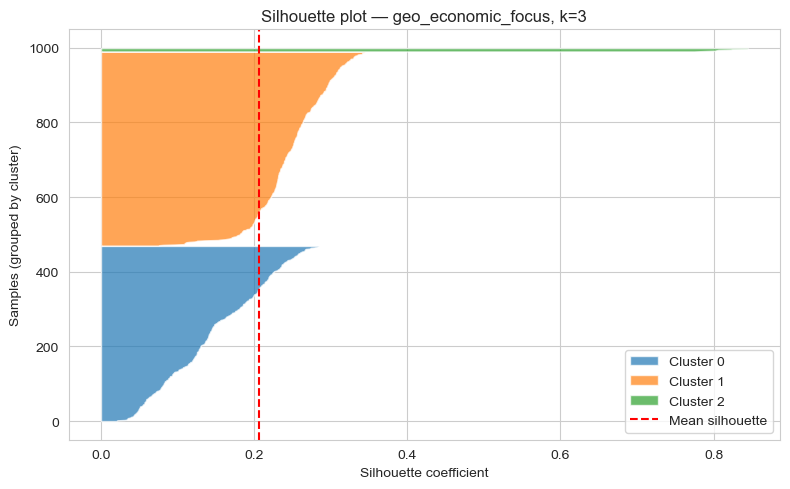

In [ ]:
sil_vals = silhouette_samples(results[best_version]["X"], mob["cluster"])
best_k_final = results[best_version]["k"]
fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 0
for i in sorted(mob["cluster"].unique()):
    vals = np.sort(sil_vals[mob["cluster"] == i])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.7, label=f"Cluster {i}")
    y_lower = y_upper
ax.axvline(sil_vals.mean(), color="red", linestyle="--", label="Mean silhouette")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Samples (grouped by cluster)")
ax.set_title(f"Silhouette plot — {best_version}, k={best_k_final}")
ax.legend()
plt.tight_layout()
plt.show()


## Definizione STEM
Definisce quali *Field_Group* sono considerati STEM (scienze naturali, ICT, ingegneria) e crea il flag `is_stem`.

In [ ]:
STEM_GROUPS = [
    "Natural sciences, mathematics and statistics",
    "Information and Communication Technologies (ICTs)",
    "Engineering, manufacturing and construction",
]
mob["is_stem"] = mob["Field_Group"].isin(STEM_GROUPS)

## Trend STEM nel tempo
Calcola la quota di mobilità STEM per anno accademico e stima un trend lineare (slope + p-value) invece di una previsione, coerente con la scarsità di anni disponibili.

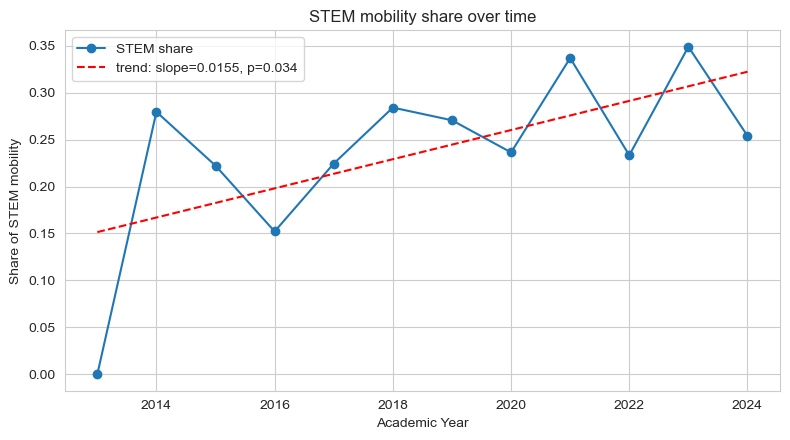

slope=0.0155  r²=0.376  p-value=0.034


In [ ]:
yearly_stem = mob.groupby("Academic Year")["is_stem"].mean().sort_index()

slope, intercept, r_value, p_value, std_err = stats.linregress(yearly_stem.index, yearly_stem.values)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(yearly_stem.index, yearly_stem.values, marker="o", label="STEM share")
ax.plot(yearly_stem.index, intercept + slope * yearly_stem.index, "--", color="red",
        label=f"trend: slope={slope:.4f}, p={p_value:.3f}")
ax.set_xlabel("Academic Year")
ax.set_ylabel("Share of STEM mobility")
ax.set_title("STEM mobility share over time")
ax.legend()
plt.tight_layout()
plt.show()

print(f"slope={slope:.4f}  r\u00b2={r_value**2:.3f}  p-value={p_value:.3f}")

## Associazione cluster — STEM
Verifica con un test chi-quadro se la quota STEM varia in modo statisticamente significativo tra i cluster individuati.

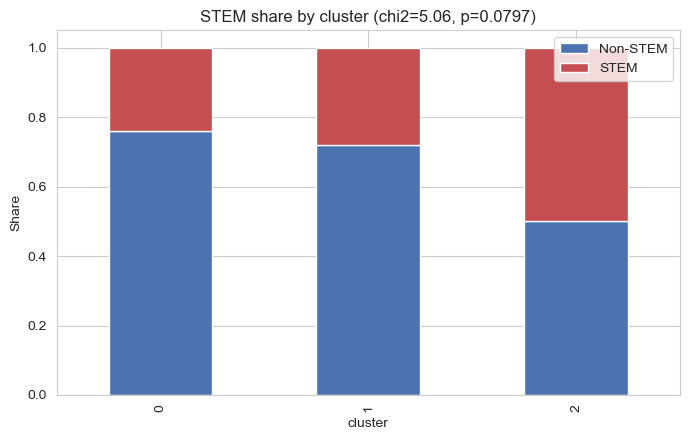

is_stem,False,True
cluster,,
0,358,112
1,375,145
2,5,5


In [ ]:
ct = pd.crosstab(mob["cluster"], mob["is_stem"], normalize="index")
chi2, p, dof, expected = stats.chi2_contingency(pd.crosstab(mob["cluster"], mob["is_stem"]))

fig, ax = plt.subplots(figsize=(7, 4.5))
ct.plot(kind="bar", stacked=True, ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_ylabel("Share")
ax.set_title(f"STEM share by cluster (chi2={chi2:.2f}, p={p:.4f})")
ax.legend(["Non-STEM", "STEM"], title="")
plt.tight_layout()
plt.show()

pd.crosstab(mob["cluster"], mob["is_stem"])